In [103]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')


In [104]:
df = pd.read_csv('customer_churn.csv') 
df.head()


,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0


In [105]:
print(df['Churn'].unique())

[1 0]


In [106]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64374 entries, 0 to 64373
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   CustomerID         64374 non-null  int64 
 1   Age                64374 non-null  int64 
 2   Gender             64374 non-null  object
 3   Tenure             64374 non-null  int64 
 4   Usage Frequency    64374 non-null  int64 
 5   Support Calls      64374 non-null  int64 
 6   Payment Delay      64374 non-null  int64 
 7   Subscription Type  64374 non-null  object
 8   Contract Length    64374 non-null  object
 9   Total Spend        64374 non-null  int64 
 10  Last Interaction   64374 non-null  int64 
 11  Churn              64374 non-null  int64 
dtypes: int64(9), object(3)
memory usage: 5.9+ MB


In [107]:
df['Churn'] = df['Churn'].astype(int)

In [108]:

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())

print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())




Shape: (64374, 12)

Columns: ['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend', 'Last Interaction', 'Churn']

Data Types:
 CustomerID            int64
Age                   int64
Gender               object
Tenure                int64
Usage Frequency       int64
Support Calls         int64
Payment Delay         int64
Subscription Type    object
Contract Length      object
Total Spend           int64
Last Interaction      int64
Churn                 int64
dtype: object

Missing Values:
 CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64


In [109]:
print("\nBasic Statistics:\n")
df.describe()



Basic Statistics:



,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000
mean,32187.500000,41.970982,31.994827,15.080234,5.400690,17.133952,541.023379,15.498850,0.473685
std,18583.317451,13.924911,17.098234,8.816470,3.114005,8.852211,260.874809,8.638436,0.499311
min,1.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,16094.250000,30.000000,18.000000,7.000000,3.000000,10.000000,313.000000,8.000000,0.000000
50%,32187.500000,42.000000,33.000000,15.000000,6.000000,19.000000,534.000000,15.000000,0.000000
75%,48280.750000,54.000000,47.000000,23.000000,8.000000,25.000000,768.000000,23.000000,1.000000
max,64374.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


In [110]:
print("\nChurn Distribution:\n", df['Churn'].value_counts())


Churn Distribution:
 Churn
0    33881
1    30493
Name: count, dtype: int64


In [111]:
df.dropna(how='all', inplace=True)

df.drop(columns=['CustomerID'], inplace=True, errors='ignore')

for col in df.select_dtypes(include=np.number).columns:
    df[col].fillna(df[col].median(), inplace=True)

for col in df.select_dtypes(include='object').columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("\nMissing Values After Cleaning:\n", df.isnull().sum())
print("\nCleaned Shape:", df.shape)



Missing Values After Cleaning:
 Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64

Cleaned Shape: (64374, 11)


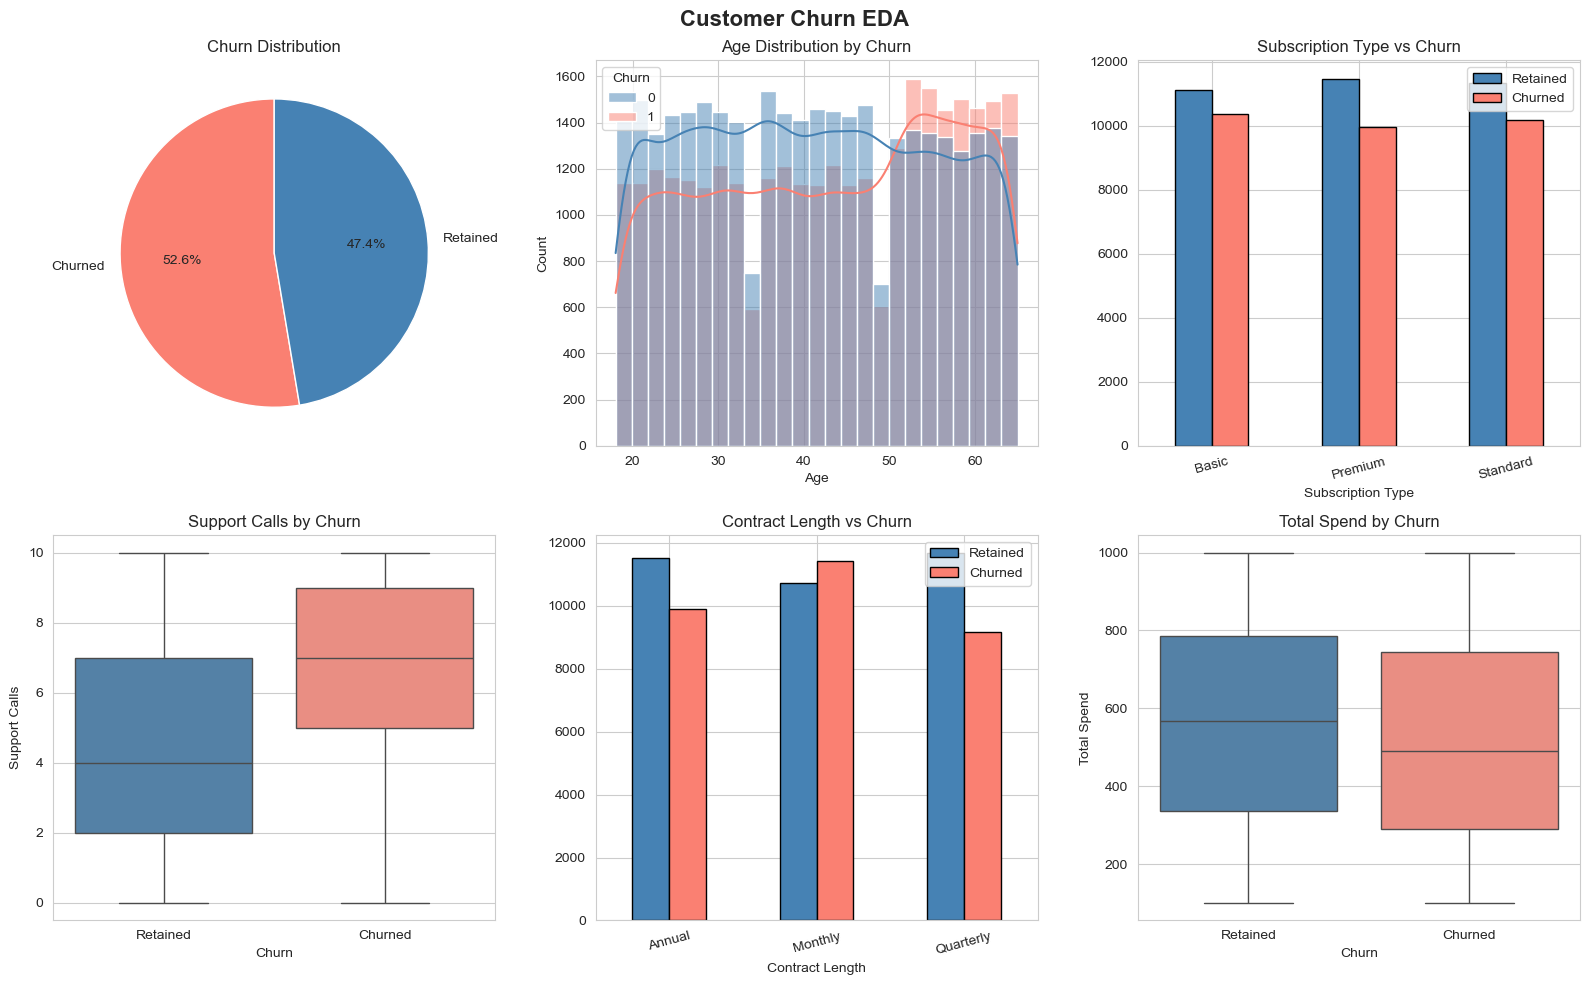

In [112]:
sns.set_style("whitegrid")

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Customer Churn EDA', fontsize=16, fontweight='bold')

# Plot 1: Churn Distribution
churn_counts = df['Churn'].value_counts()
axes[0, 0].pie(churn_counts, labels=['Churned', 'Retained'],
               autopct='%1.1f%%', colors=['salmon', 'steelblue'], startangle=90)
axes[0, 0].set_title('Churn Distribution')

# Plot 2: Age Distribution by Churn
sns.histplot(data=df, x='Age', hue='Churn', kde=True, ax=axes[0, 1],
             palette={0: 'steelblue', 1: 'salmon'}, bins=25)
axes[0, 1].set_title('Age Distribution by Churn')

# Plot 3: Subscription Type vs Churn
sub_churn = df.groupby(['Subscription Type', 'Churn']).size().unstack(fill_value=0)
sub_churn.plot(kind='bar', ax=axes[0, 2], color=['steelblue', 'salmon'], edgecolor='black')
axes[0, 2].set_title('Subscription Type vs Churn')
axes[0, 2].tick_params(axis='x', rotation=15)
axes[0, 2].legend(['Retained', 'Churned'])

# Plot 4: Support Calls by Churn
sns.boxplot(x='Churn', y='Support Calls', data=df, ax=axes[1, 0],
            palette={'0': 'steelblue', '1': 'salmon'})
axes[1, 0].set_title('Support Calls by Churn')
axes[1, 0].set_xticklabels(['Retained', 'Churned'])

# Plot 5: Contract Length vs Churn
contract_churn = df.groupby(['Contract Length', 'Churn']).size().unstack(fill_value=0)
contract_churn.plot(kind='bar', ax=axes[1, 1], color=['steelblue', 'salmon'], edgecolor='black')
axes[1, 1].set_title('Contract Length vs Churn')
axes[1, 1].tick_params(axis='x', rotation=15)
axes[1, 1].legend(['Retained', 'Churned'])

# Plot 6: Total Spend by Churn
sns.boxplot(x='Churn', y='Total Spend', data=df, ax=axes[1, 2],
            palette={'0': 'steelblue', '1': 'salmon'})
axes[1, 2].set_title('Total Spend by Churn')
axes[1, 2].set_xticklabels(['Retained', 'Churned'])

plt.tight_layout()
plt.savefig('task3_eda.png', dpi=150)
plt.show()


In [113]:

# Encode Categorical Features
df_encoded = df.copy()
le = LabelEncoder()

# Label encode binary/ordinal categoricals
for col in df_encoded.select_dtypes(include='object').columns:
    df_encoded[col] = le.fit_transform(df_encoded[col])

print("\nEncoded DataFrame:\n")
df_encoded.head()



Encoded DataFrame:



,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,22,0,25,14,4,27,0,1,598,9,1
1,41,0,28,28,7,13,2,1,584,20,0
2,47,1,27,10,2,29,1,0,757,21,0
3,35,1,9,12,5,17,1,2,232,18,0
4,53,0,58,24,9,2,2,0,533,18,0


In [114]:

# Feature Selection
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTraining samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")




Training samples: 51499, Test samples: 12875


In [115]:

# Model 1: Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

# Model 2: Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)


In [116]:

# Evaluate Models
print("\n" + "="*50)
print("RANDOM FOREST RESULTS")
print("="*50)
print(f"Accuracy: {accuracy_score(y_test, rf_pred):.4f}")
print("\nClassification Report:\n", classification_report(y_test, rf_pred))

print("\n" + "="*50)
print("LOGISTIC REGRESSION RESULTS")
print("="*50)
print(f"Accuracy: {accuracy_score(y_test, lr_pred):.4f}")
print("\nClassification Report:\n", classification_report(y_test, lr_pred))



RANDOM FOREST RESULTS
Accuracy: 0.9990

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      6776
           1       1.00      1.00      1.00      6099

    accuracy                           1.00     12875
   macro avg       1.00      1.00      1.00     12875
weighted avg       1.00      1.00      1.00     12875


LOGISTIC REGRESSION RESULTS
Accuracy: 0.8256

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.83      0.83      6776
           1       0.81      0.82      0.82      6099

    accuracy                           0.83     12875
   macro avg       0.83      0.83      0.83     12875
weighted avg       0.83      0.83      0.83     12875



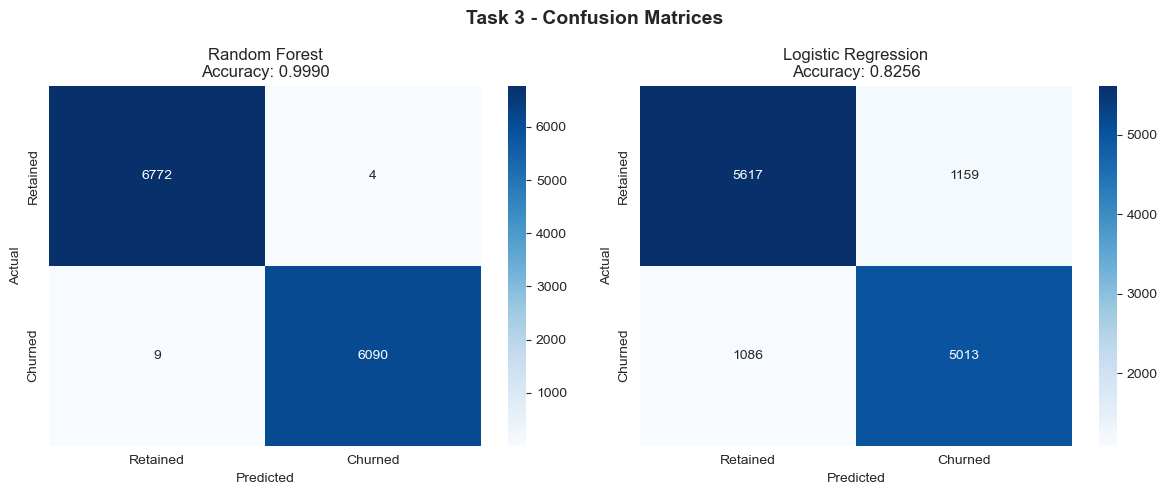

In [117]:
# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Task 3 - Confusion Matrices', fontsize=14, fontweight='bold')

for ax, pred, title in zip(
    axes,
    [rf_pred, lr_pred],
    ['Random Forest', 'Logistic Regression']
):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Retained', 'Churned'],
                yticklabels=['Retained', 'Churned'])
    ax.set_title(f'{title}\nAccuracy: {accuracy_score(y_test, pred):.4f}')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('task3_confusion_matrix.png', dpi=150)
plt.show()


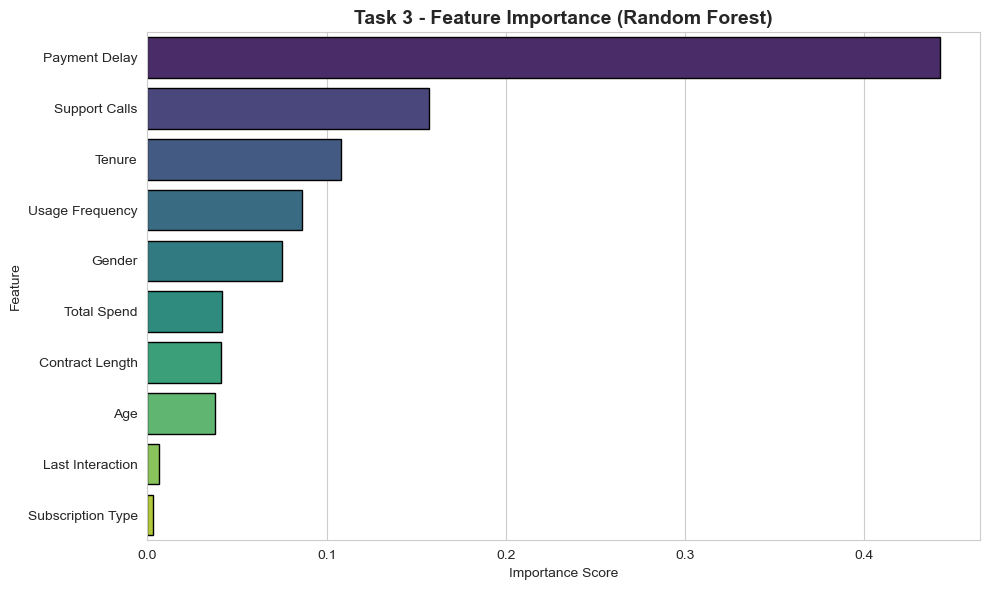


Top 5 Features Influencing Churn:
Payment Delay      0.442542
Support Calls      0.157326
Tenure             0.108052
Usage Frequency    0.086262
Gender             0.075345
dtype: float64


In [118]:

# Feature Importance
feature_importance = pd.Series(
    rf_model.feature_importances_, index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importance.values, y=feature_importance.index,
            palette='viridis', edgecolor='black')
plt.title('Task 3 - Feature Importance (Random Forest)', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('task3_feature_importance.png', dpi=150)
plt.show()

print("\nTop 5 Features Influencing Churn:")
print(feature_importance.head())


In [119]:
# Conclusion 
print("\n" + "="*50)
print("CONCLUSION")
print("="*50)
print(f"Random Forest Accuracy    : {accuracy_score(y_test, rf_pred):.4f}")
print(f"Logistic Regression Accuracy: {accuracy_score(y_test, lr_pred):.4f}")
print("\nKey Insights:")
print("- Support Calls and Payment Delay are strong churn predictors.")
print("- Monthly contract customers churn more than Annual contract customers.")
print("- Customers with lower Total Spend tend to churn more.")


CONCLUSION
Random Forest Accuracy    : 0.9990
Logistic Regression Accuracy: 0.8256

Key Insights:
- Support Calls and Payment Delay are strong churn predictors.
- Monthly contract customers churn more than Annual contract customers.
- Customers with lower Total Spend tend to churn more.
